In [240]:
import sys
sys.path.append('..')

import pickle
import numpy as np
from matplotlib.pyplot import cm
import pandas as pd
from numpy import linspace
import matplotlib.pyplot as plt
import math

from os import listdir
from os.path import isfile, join

from utils.data_parsing_tools import get_lot
from utils.general_tools import pd_to_param_holder
from utils.data_processing_tools import full_preprocessing_pipeline, bring_to_original_range
from utils.modeling_tools import perform_modeling_linear
from utils.regression_tools import forecast_test_linear
from utils.display_tools import load_best_forecasts, display_predictions

In [241]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Display the forecasts and save them properly into a table

In [242]:
data = pickle.load(open("../saves_and_results/cache_endog.p", "rb"))
exogs = pickle.load(open("../saves_and_results/cache_exogs.p", "rb"))

In [4]:
loc = "Moehne"
direction = "asc0"
row_length = 2

In [5]:
d = data[loc][direction]
y_ = d.loc[d.index.year == 2020]

/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:79: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = np.where(d.index.weekofyear == 1)[0]


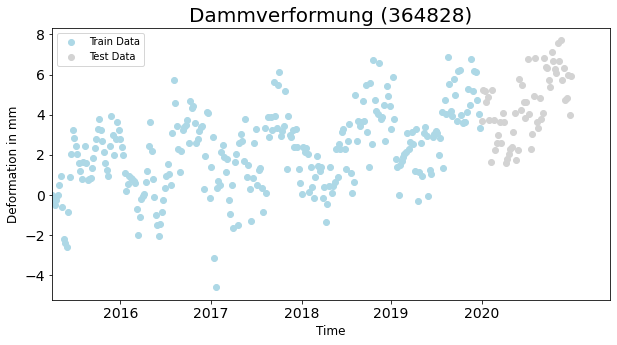

In [6]:
display_predictions(d,pd.DataFrame(), [], key = "364828", x_lim=[0,375])

### Baseline

In [235]:
model_spec, forecasts = load_best_forecasts("results/psi_baseline_f", lot=False)

In [236]:
model_spec[model_spec.Index == 364828]

,Index,MSE,MAE,MAPE,P,D,Q,F,STAU,T,...,Interaction,Estimator,n_estimator,max_depth,learning_rate,MSE_1step,MAE_1step,AIC,MAPE_1step,Index_2
ada,364828,6.112785,1.840165,0.418211,0,NaN,NaN,0,[0],[0],...,0,dt,50.0,NaN,1.0,NaN,NaN,NaN,NaN,ada
forest,364828,5.647326,1.738896,0.410673,0,NaN,NaN,0,[0],[0],...,0,NaN,50.0,NaN,NaN,NaN,NaN,NaN,NaN,forest
sarimax,364828,3.062763,1.255183,0.294929,0,0.0,0.0,0,[0],[0],...,0,NaN,NaN,NaN,NaN,3.062763,1.255183,0.294929,-172.089915,sarimax
linear,364828,2.969806,1.217534,0.290145,0,NaN,NaN,0,[0],[0],...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,linear


In [237]:
preds = pd.concat([forecasts[x]["364828"] for x in forecasts.keys()],axis=1)
preds.columns = [x for x in forecasts.keys()] 
mae = pd.DataFrame(np.nanmean(np.abs(preds.values -np.repeat(y_["364828"].values[:,np.newaxis],4, axis=1)),axis=0), index=preds.columns, columns=["MAE"])
mae

,MAE
sarimax,1.166636
forest,2.228922
linear,1.152203
ada,2.219941


In [ ]:
,


/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:79: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = np.where(d.index.weekofyear == 1)[0]


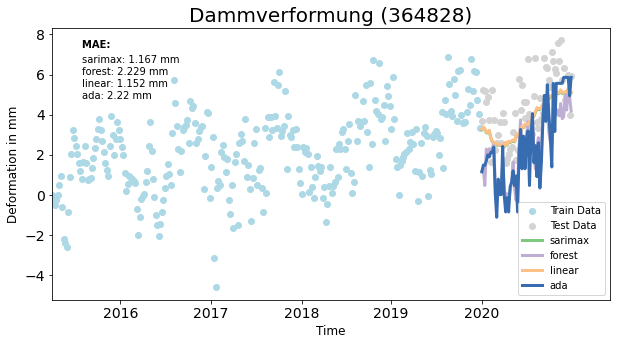

In [238]:
display_predictions(d,preds, mae, key = "364828", x_lim=[0,375])

In [239]:
stack = []
for key in y_.keys():
    preds = pd.concat([forecasts[x][key] for x in forecasts.keys()],axis=1)
    preds.columns = [x for x in forecasts.keys()] 
    mae = pd.DataFrame(np.nanmean(np.abs(preds.values -np.repeat(y_[key].values[:,np.newaxis],4, axis=1)),axis=0), index=preds.columns, columns=["MAE"])
    stack.append(mae)
best_class = {}
for x in stack[0].index:
    best_class[x] = 0
for x in stack:
    winner = x.sort_values(by="MAE").iloc[0].name
    best_class[winner] += 1
print(pd.DataFrame([best_class[x] for x in best_class.keys()], index= list(best_class.keys()), columns=["Best model"]))
pd.DataFrame(pd.concat(stack, axis=1).mean(axis=1),columns=["MAE"])

         Best model
sarimax           7
forest            0
linear           19
ada               3


,MAE
sarimax,2.831106
forest,3.029510
linear,2.072776
ada,2.879583


### One step version

In [230]:
model_spec, forecasts = load_best_forecasts("results/psi_one_step_ahead_f", lot=False)

In [231]:
model_spec[model_spec.Index == 364828]

,Index,MSE,MAE,MSE_1step,MAE_1step,AIC,MAPE,MAPE_1step,P,D,...,T,M_Stau,M_T,Decompose,Interaction,Estimator,n_estimator,max_depth,learning_rate,Index_2
var,364828,1.455908,0.131654,3.169156,1.253067,0.248270,0.301087,-10030.750094,1,NaN,...,[0],0,0,0,0,NaN,NaN,NaN,NaN,var
ada,364828,2.843826,1.073710,NaN,NaN,NaN,0.298631,NaN,1,NaN,...,[0],0,0,0,0,linear,50.0,NaN,1.0,ada
forest,364828,3.488859,1.373004,NaN,NaN,NaN,0.297642,NaN,1,NaN,...,[0],0,0,0,0,NaN,250.0,7.0,NaN,forest
sarimax,364828,2.932096,0.470943,7.711865,1.732676,0.317541,0.535052,-316.259627,1,0.0,...,[0],0,0,0,0,NaN,NaN,NaN,NaN,sarimax
linear,364828,1.833593,0.569834,NaN,NaN,NaN,0.223421,NaN,1,NaN,...,[0],0,0,0,0,NaN,NaN,NaN,NaN,linear


In [232]:
preds = pd.concat([forecasts[x]["364828"] for x in forecasts.keys()],axis=1)
preds.columns = [x for x in forecasts.keys()] 
mae = pd.DataFrame(np.nanmean(np.abs(preds.values -np.repeat(y_["364828"].values[:,np.newaxis],4, axis=1)),axis=0), index=preds.columns, columns=["MAE"])
mae

,MAE
sarimax,1.317484
forest,1.424314
linear,1.001508
ada,1.345520


/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:79: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = np.where(d.index.weekofyear == 1)[0]


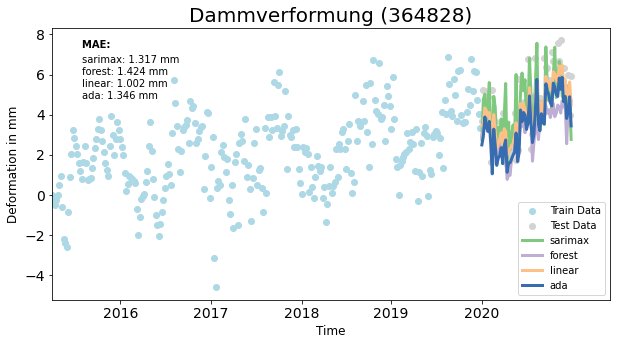

In [233]:
display_predictions(d,preds, mae, key = "364828", x_lim=[0,375])

In [234]:
stack = []
for key in y_.keys():
    preds = pd.concat([forecasts[x][key] for x in forecasts.keys()],axis=1)
    preds.columns = [x for x in forecasts.keys()] 
    mae = pd.DataFrame(np.nanmean(np.abs(preds.values -np.repeat(y_[key].values[:,np.newaxis],4, axis=1)),axis=0), index=preds.columns, columns=["MAE"])
    stack.append(mae)
best_class = {}
for x in stack[0].index:
    best_class[x] = 0
for x in stack:
    winner = x.sort_values(by="MAE").iloc[0].name
    best_class[winner] += 1
print(pd.DataFrame([best_class[x] for x in best_class.keys()], index= list(best_class.keys()), columns=["Best model"]))
pd.DataFrame(pd.concat(stack, axis=1).mean(axis=1),columns=["MAE"])

         Best model
sarimax           3
forest            2
linear           21
ada               3


,MAE
sarimax,2.388407
forest,2.422926
linear,1.973966
ada,2.276318


### Full exogenous

In [226]:
model_spec, forecasts = load_best_forecasts("results/psi_no_autoreg_f", lot=False)

In [227]:
preds = pd.concat([forecasts[x]["364828"] for x in forecasts.keys()],axis=1)
preds.columns = [x for x in forecasts.keys()] 
mae = pd.DataFrame(np.nanmean(np.abs(preds.values -np.repeat(y_["364828"].values[:,np.newaxis],4, axis=1)),axis=0), index=preds.columns, columns=["MAE"])
mae

,MAE
sarimax,1.253425
forest,0.967410
linear,1.164572
ada,0.947181


/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:79: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = np.where(d.index.weekofyear == 1)[0]


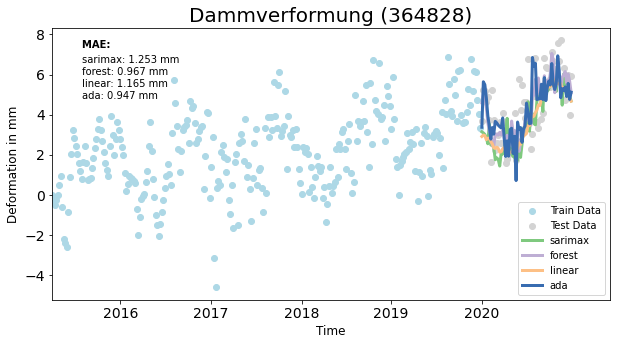

In [228]:
display_predictions(d,preds, mae, key = "364828", x_lim=[0,375])

In [229]:
stack = []
for key in y_.keys():
    preds = pd.concat([forecasts[x][key] for x in forecasts.keys()],axis=1)
    preds.columns = [x for x in forecasts.keys()] 
    mae = pd.DataFrame(np.nanmean(np.abs(preds.values -np.repeat(y_[key].values[:,np.newaxis],4, axis=1)),axis=0), index=preds.columns, columns=["MAE"])
    stack.append(mae)
best_class = {}
for x in stack[0].index:
    best_class[x] = 0
for x in stack:
    winner = x.sort_values(by="MAE").iloc[0].name
    best_class[winner] += 1
print(pd.DataFrame([best_class[x] for x in best_class.keys()], index= list(best_class.keys()), columns=["Best model"]))
pd.DataFrame(pd.concat(stack, axis=1).mean(axis=1),columns=["MAE"])

         Best model
sarimax           1
forest            3
linear           17
ada               8


,MAE
sarimax,2.728498
forest,2.313963
linear,2.111803
ada,2.273306


### Full search

In [222]:
model_spec, forecasts = load_best_forecasts("results/psi_full_search_f", lot=False)

In [223]:
preds = pd.concat([forecasts[x]["364828"] for x in forecasts.keys()],axis=1)
preds.columns = [x for x in forecasts.keys()] 
mae = pd.DataFrame(np.nanmean(np.abs(preds.values -np.repeat(y_["364828"].values[:,np.newaxis],3, axis=1)),axis=0), index=preds.columns, columns=["MAE"])
mae

,MAE
forest,1.014775
linear,1.023654
ada,1.139438


/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:79: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = np.where(d.index.weekofyear == 1)[0]


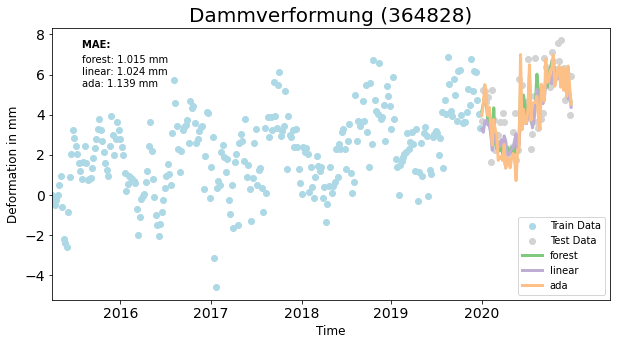

In [224]:
display_predictions(d,preds, mae, key = "364828", x_lim=[0,375])

In [225]:
stack = []
for key in y_.keys():
    preds = pd.concat([forecasts[x][key] for x in forecasts.keys()],axis=1)
    preds.columns = [x for x in forecasts.keys()] 
    mae = pd.DataFrame(np.nanmean(np.abs(preds.values -np.repeat(y_[key].values[:,np.newaxis],3, axis=1)),axis=0), index=preds.columns, columns=["MAE"])
    stack.append(mae)
best_class = {}
for x in stack[0].index:
    best_class[x] = 0
for x in stack:
    winner = x.sort_values(by="MAE").iloc[0].name
    best_class[winner] += 1
print(pd.DataFrame([best_class[x] for x in best_class.keys()], index= list(best_class.keys()), columns=["Best model"]))
pd.DataFrame(pd.concat(stack, axis=1).mean(axis=1),columns=["MAE"])

        Best model
forest           7
linear          18
ada              4


,MAE
forest,2.167375
linear,1.997516
ada,2.182077


### Full search no interaction

In [219]:
model_spec, forecasts = load_best_forecasts("results/psi_full_search_interaction_f", lot=False)

In [220]:
preds = pd.concat([forecasts[x]["364828"] for x in forecasts.keys()],axis=1)
preds.columns = [x for x in forecasts.keys()] 
mae = pd.DataFrame(np.nanmean(np.abs(preds.values -np.repeat(y_["364828"].values[:,np.newaxis],4, axis=1)),axis=0), index=preds.columns, columns=["MAE"])
mae

,MAE
sarimax,1.221170
forest,1.014947
linear,1.010516
ada,1.046056


/home/stein/project_repos/dam/full_baseline/forecasting_analysis/utils/display_tools.py:79: FutureWarning: weekofyear and week have been deprecated, please use DatetimeIndex.isocalendar().week instead, which returns a Series. To exactly reproduce the behavior of week and weekofyear and return an Index, you may call pd.Int64Index(idx.isocalendar().week)
  tickPos = np.where(d.index.weekofyear == 1)[0]


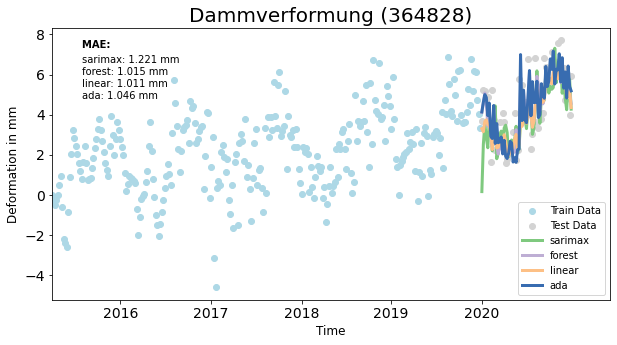

In [221]:
display_predictions(d,preds, mae, key = "364828", x_lim=[0,375])

In [217]:
pd.DataFrame([best_class[x] for x in best_class.keys()], index= list(best_class.keys()), columns=["Best model"])

,Best model
sarimax,3
forest,5
linear,17
ada,4


In [218]:
stack = []
for key in y_.keys():
    preds = pd.concat([forecasts[x][key] for x in forecasts.keys()],axis=1)
    preds.columns = [x for x in forecasts.keys()] 
    mae = pd.DataFrame(np.nanmean(np.abs(preds.values -np.repeat(y_[key].values[:,np.newaxis],4, axis=1)),axis=0), index=preds.columns, columns=["MAE"])
    stack.append(mae)
best_class = {}
for x in stack[0].index:
    best_class[x] = 0
for x in stack:
    winner = x.sort_values(by="MAE").iloc[0].name
    best_class[winner] += 1
print(pd.DataFrame([best_class[x] for x in best_class.keys()], index= list(best_class.keys()), columns=["Best model"]))
pd.DataFrame(pd.concat(stack, axis=1).mean(axis=1),columns=["MAE"])

         Best model
sarimax           3
forest            5
linear           17
ada               4


,MAE
sarimax,2.351497
forest,2.158233
linear,1.997461
ada,2.145422


### Rebuild model

In [199]:
selection = model_spec[model_spec.Index == 364828]

In [200]:
# some ugly refractor because of loading: 
for y in ["T", "STAU"]:
    stack = []
    for x in selection.index:
            stack.append(np.array(selection.loc[x,  y][1:-1].split(" ")).astype(int))
    selection[y] = stack

/tmp/ipykernel_2353804/2798565191.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selection[y] = stack


In [201]:
selection["Index"] = selection.index

/tmp/ipykernel_2353804/2736345666.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selection["Index"] = selection.index


In [202]:
combo = pd_to_param_holder(selection, "linear")

In [203]:
(train,
test,
max_data,
min_data,
trend,
seasonality,
test_trend,
test_seasonality) = (
full_preprocessing_pipeline(data["Moehne"]["asc0"], exogs["Moehne"], combo, model_search=False)
)

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [204]:
model, trend_step = perform_modeling_linear(train[0]["364828"], train[1], combo)
pred = forecast_test_linear(test[0]["364828"],test[1], combo, model, trend_step)

In [205]:
p = "364828"
Y, Y_hat = bring_to_original_range(
    test[0][p],
    pred[0],
    max_data[p],
    min_data[p],
    (test_trend[p] if isinstance(trend, pd.DataFrame) else None),
    (test_seasonality[p] if isinstance(seasonality, pd.DataFrame) else None),
    data["Moehne"]["asc0"],
    p
)

In [206]:
np.nanmean(np.abs(Y_hat.values -y_["364828"].values))

1.0105160293029376

In [207]:
# Something is wrong with the error calc and the filling. Fix it.

In [208]:
names = perform_modeling_linear(train[0]["364828"], train[1], combo, return_temporary=True).columns
final = model.summary().tables[1]
final = pd.DataFrame(final.data[1:], index = names)

In [209]:
final = final[1]

In [210]:
pd.DataFrame(final.values, columns=["Value"], index=final.index)

,Value
sin_order_1,-0.0586
cos_order_1,0.0271
sin_order_2,-0.0078
cos_order_2,0.1160
W_0,0.0092
T_0,2.0423
INTER,-2.0958
1,0.3648
2,0.0347
const,0.3482
